# Differentiable Optimization

An optimization problem can be a layer. For a quadratic objective

$$
\phi(z,x)=\frac12 z^\top A z-b_\theta(x)^\top z,
\qquad A=L L^\top+\lambda I,
$$

the stationarity condition is

$$
\nabla_z\phi(z,x)=Az-b_\theta(x)=0.
$$

The solution can be obtained directly by $Az=b_\theta(x)$, or by applying the
fixed-point map

$$
T(z)=z-\eta(Az-b_\theta(x)).
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [8](https://jseluis.github.io/silva-networks/paper/references/#ref-8), [9](https://jseluis.github.io/silva-networks/paper/references/#ref-9), [40](https://jseluis.github.io/silva-networks/paper/references/#ref-40). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Exact Solve and Fixed-Point Solve

The package layer exposes both the direct linear solve and the iterative
fixed-point version. This makes it easy to debug the optimization layer before
using it inside a larger model.

In [3]:
from silva_networks import silva_quadratic_optimization_layer

layer = silva_quadratic_optimization_layer(
    in_dim=3,
    state_dim=2,
    ridge=1.5,
    step_size=0.2,
    config=SolverConfig(max_iter=60, alpha=1.0, tol=1e-7),
    reengage=False,
).to(device)
x = torch.tensor([[1.0, -0.5, 0.25], [-0.2, 0.4, 0.7]], device=device)
iterative = layer(x)
exact = layer.exact_solution(x)
torch.max(torch.abs(iterative - exact)).detach().cpu()

tensor(4.4703e-08)

## Energy Decrease

The fixed-point map is gradient descent on $\phi$. The sequence below records
the objective value by hand, one update at a time.

In [4]:
z = torch.zeros_like(exact)
energies = []
for _ in range(25):
    energies.append(float(layer.energy(z, x).mean().detach().cpu()))
    z = layer.transition(z, x)
energies.append(float(layer.energy(z, x).mean().detach().cpu()))
energies[:3], energies[-1]

([0.0, -0.026493709534406662, -0.0331171378493309], -0.03532494604587555)

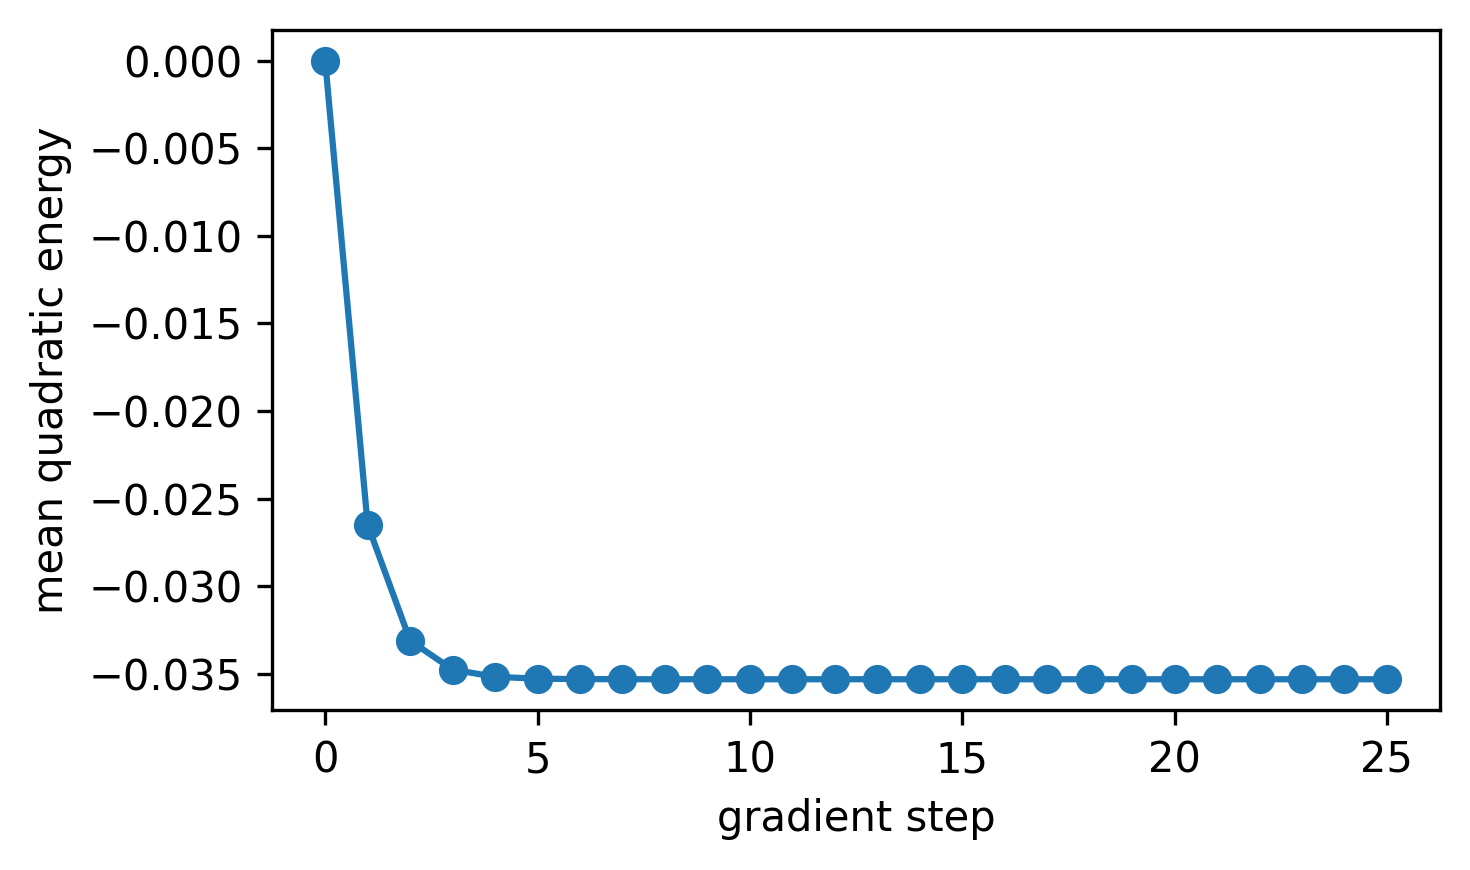

In [5]:
plt.figure(figsize=(5.0, 3.0))
plt.plot(energies, marker="o")
plt.xlabel("gradient step")
plt.ylabel("mean quadratic energy")
plt.tight_layout()

## Gradients Through the Layer

The objective parameters are PyTorch parameters. A downstream loss can update
the input-to-$b$ map and the positive-definite matrix factor.

In [6]:
target = torch.zeros_like(iterative)
optim = torch.optim.Adam(layer.parameters(), lr=0.01)
optim.zero_grad()
solution = layer(x)
loss = (solution - target).square().mean()
loss.backward()
optim.step()

float(loss.detach().cpu()), layer.b_proj.weight.grad is not None, layer.factor.grad is not None

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


(0.014129972085356712, True, True)

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770099
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.

## Where to Go Next

| Question | Page |
| --- | --- |
| Where is a constrained layer executed as a script? | [Constrained Optimization Example](https://jseluis.github.io/silva-networks/examples/constrained-optimization/) |
| Which optimization layers and constraints are public? | [Optimization API](https://jseluis.github.io/silva-networks/api/optimization/) |
| How do optimization layers fit the implicit viewpoint? | [Implicit Layers Bridge](https://jseluis.github.io/silva-networks/learn/implicit-bridge/) |
